
# Problem 1

My approach uses the T5-small model from Hugging Face. The setup is essentially the same as Assignment 7 Q4 with these changes:
- Use the tokenizer that comes with the T5 model to simplify reading the data in
- The training loop fine-tunes the pretrained weights on the SQuAD dataset so that the model learns to generate answers from question and context inputs.  
- Abbreviated context is included in the training loop (I did not include context info in Assignment 7 Q4)
- The `eval` logic is simplified by taking advantage of the model's included `generate` function
- The training data is split into training and evaluation data sets. This is something I wanted to do for Assignment 7, but ran out of time.

### References 
I found these sources helpful in figuring out how to adapt the training loop and work with the T5 model:
- https://huggingface.co/learn/llm-course/chapter3/4
- https://huggingface.co/docs/transformers/tasks/translation


Ensure I'm logged into Hugging Face

In [11]:
from huggingface_hub import HfApi
api = HfApi()
try:
    who = api.whoami()
    print("Logged in as:", who["name"])
except Exception as e:
    print("Not authenticated:", e)

Logged in as: InfestedCoder


## Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72

import os
import random
import numpy as np
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import transformers
from transformers import T5Tokenizer, T5ForConditionalGeneration

MODEL_PATH= 'EP_models/'
os.environ['HF_HOME']= MODEL_PATH  # before import transformers
os.environ['HF_DATASETS_CACHE']= 'EP_datasets/'  # dataset cache

Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"torch version= {torch.__version__}")
print(f"transformers version= {transformers.__version__}")
print(f"device= {Device}")

torch version= 2.10.0
transformers version= 5.1.0
device= cuda:0


## Hyperparameters 

Through experimentation, I found batch size of 16 rather than 8, a small learning rate (1e-4), and including 500 characters from the context rather than 200 or 300, allowed the fine-tuning we do below to have slightly more impact on the base T5 model and demonstrate a slight decrease in loss during training.

In [12]:
MODEL_NAME = 't5-small'

BATCH_SIZE = 16
EPOCHS = 3
LR = 1e-4

MAX_INPUT_LEN = 256
MAX_OUTPUT_LEN = 32

TRAIN_SIZE = 2000
VAL_SIZE = 500

CONTEXT_CHARS = 500

Save part of the dataset to evaluate the model

In [13]:
Dataset_squad = load_dataset('squad', split=f'train[:{TRAIN_SIZE}]')

Dataset_squad_val = load_dataset('squad', split=f'validation[:{VAL_SIZE}]')

print(f"#train= {len(Dataset_squad)}")
print(f"#val=   {len(Dataset_squad_val)}")
print(Dataset_squad[0].keys())

#train= 2000
#val=   500
dict_keys(['id', 'title', 'context', 'question', 'answers'])


This class below is simplified from the Assignment 7 by using the model's tokenizer. 

Context is stripped to only be the first few hundred characters. 

For T5 training we supply three tensors.

- `input_ids` are token IDs representing the input sequence "question: {question} context: {context}".
- `attention_mask` indicates which tokens are real (1) versus padding (0), preventing the model from attending to padding tokens.
- `labels` are token IDs representing the target sequence (the answer). Padding tokens in the labels are replaced with -100 so they are ignored when computing the training loss.

### Reference
This doc was helpful in understanding the three tensors:
https://huggingface.co/docs/transformers/model_doc/t5

In [14]:
class QADatasetT5(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_input_len=256, max_output_len=32, context_chars=300):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_output_len = max_output_len
        self.context_chars = context_chars

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        ex = self.dataset[idx]

        question = ex['question'].strip()

        # Only use the first part of the context
        context = ex['context'].strip()[:self.context_chars]

        # Use the first listed answer for training
        answer_text = ex['answers']['text'][0].strip()
        
        input_text = f"question: {question}  context: {context}"
        target_text = answer_text

        enc = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        dec = self.tokenizer(
            target_text,
            max_length=self.max_output_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)
        labels = dec['input_ids'].squeeze(0)

        # ignore padding tokens in the loss
        labels[labels == self.tokenizer.pad_token_id] = -100

        return input_ids, attention_mask, labels

In [85]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(Device)

Dataset_train = QADatasetT5(
    Dataset_squad,
    tokenizer,
    max_input_len=MAX_INPUT_LEN,
    max_output_len=MAX_OUTPUT_LEN,
    context_chars=CONTEXT_CHARS
)

Dloader_train = DataLoader(Dataset_train, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())

print(f"#train batches= {len(Dloader_train)}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

#train batches= 125


In [86]:
input_ids, attention_mask, labels = next(iter(Dloader_train))

print(f"input_ids.shape = {input_ids.shape}")
print(f"attention_mask.shape = {attention_mask.shape}")
print(f"labels.shape = {labels.shape}")

sample_in = tokenizer.decode(input_ids[0], skip_special_tokens=True)
sample_lab_ids = labels[0].clone()
sample_lab_ids[sample_lab_ids == -100] = tokenizer.pad_token_id
sample_out = tokenizer.decode(sample_lab_ids, skip_special_tokens=True)

print("\nSample input:\n")
print(sample_in)

print("\nSample target:\n")
print(sample_out)

input_ids.shape = torch.Size([16, 256])
attention_mask.shape = torch.Size([16, 256])
labels.shape = torch.Size([16, 32])

Sample input:

question: Who did Chopin attend the Lower Rhenish Music Festival with? context: In the spring of 1834, Chopin attended the Lower Rhenish Music Festival in Aix-la-Chapelle with Hiller, and it was there that Chopin met Felix Mendelssohn. After the festival, the three visited Düsseldorf, where Mendelssohn had been appointed musical director. They spent what Mendelssohn described as "a very agreeable day", playing and discussing music at his piano, and met Friedrich Wilhelm Schadow, director of the Academy of Art, and some of his eminent pupils such as Lessing, Bendemann, Hilde

Sample target:

Hiller


In [87]:
def train(model, epochs=2, info=True):
    import sys

    optim = torch.optim.AdamW(model.parameters(), lr=LR)

    model.train()
    losses = []
    N = len(Dloader_train)
    
    for e in range(epochs):
        for b, (input_ids, attention_mask, labels) in enumerate(Dloader_train):
            input_ids = input_ids.to(Device, non_blocking=True)
            attention_mask = attention_mask.to(Device, non_blocking=True)
            labels = labels.to(Device, non_blocking=True)

            optim.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optim.step()
            
            losses.append(loss.item())

            if info:
                sys.stderr.write(f"\rEpoch: {e+1}/{epochs} | Iteration: {b:4d}/{N:4d} | Loss: {loss.item():3.2f}")
                sys.stderr.flush()
    
    return losses

In [88]:
%%time

train_losses = train(model, epochs=EPOCHS, info=True)

Epoch: 3/3 | Iteration:  124/ 125 | Loss: 1.39

CPU times: total: 1min 49s
Wall time: 1min 35s


I was curious what the loss looks like when fine-tuning a pre-trained model, so I included this chart

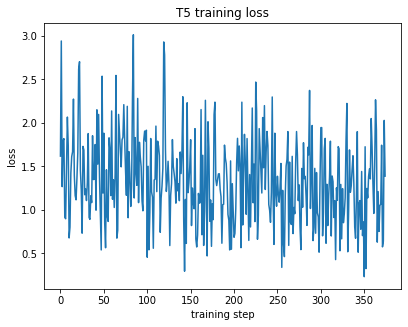

In [89]:
plt.plot(train_losses)
plt.xlabel('training step')
plt.ylabel('loss')
plt.title('T5 training loss')
plt.show()

The chart is noisy because I'm looking at loss at each training step rather than averaged across each epoch. There might be a slight downward trend that would play out with more epochs, but even from the first training steps there are places where it's clear the T5 model already can predict the answer as we see low loss numbers below 1.0 in the first 25 steps or so.

We use the model's `tokenizer` again to get the input format right and then use the model's `generate` function ti get the answer.

In [90]:
def generate_answer(model, tokenizer, question, context, max_input_len=256, max_output_len=32):
    model.eval()

    input_text = f"question: {question}  context: {context}"
    enc = tokenizer(
        input_text,
        max_length=max_input_len,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = enc['input_ids'].to(Device)
    attention_mask = enc['attention_mask'].to(Device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_output_len,
            num_beams=4,
            early_stopping=True
        )

    pred = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return pred

Pull some random questions from our evaluation dataset and see how good the model is at generating the answers

In [91]:
def eval_rnd(model, tokenizer, n=5):
    model.eval()

    for _ in range(n):
        i = random.randint(0, len(Dataset_squad_val) - 1)
        ex = Dataset_squad_val[i]

        question = ex['question'].strip()
        context = ex['context'].strip()[:CONTEXT_CHARS]
        true_answer = ex['answers']['text'][0].strip()        

        pred_answer = generate_answer(
            model,
            tokenizer,
            question,
            context,
            max_input_len=MAX_INPUT_LEN,
            max_output_len=MAX_OUTPUT_LEN
        )

        print("="*80)
        print(f"QUESTION: {question}")
        print(f"\nCONTEXT: {context}")
        print(f"\nTRUE: {true_answer}")
        print(f"PRED: {pred_answer}")
        print()

In [92]:
eval_rnd(model, tokenizer, n=5)

QUESTION: How much did it cost to build Levi's Stadium?

CONTEXT: On May 21, 2013, NFL owners at their spring meetings in Boston voted and awarded the game to Levi's Stadium. The $1.2 billion stadium opened in 2014. It is the first Super Bowl held in the San Francisco Bay Area since Super Bowl XIX in 1985, and the first in California since Super Bowl XXXVII took place in San Diego in 2003.

TRUE: $1.2 billion
PRED: $1.2 billion

QUESTION: How many games did the Broncos lose during their regular 2015 season?

CONTEXT: Following their loss in the divisional round of the previous season's playoffs, the Denver Broncos underwent numerous coaching changes, including a mutual parting with head coach John Fox (who had won four divisional championships in his four years as Broncos head coach), and the hiring of Gary Kubiak as the new head coach. Under Kubiak, the Broncos planned to install a run-oriented offense with zone blocking to blend in with quarterback Peyton Manning's shotgun passing sk

This looks pretty good. The wrong answers are still in the right domain, e.g. 

- white instead of blue, both are colors
- 39 instead of 20, both are numbers

We can do the same cosine similarity test we did in assignment 7

Below, we're able to re-use most of what we had in assignment 7 and can even clean some things up by using the model's `tokenizer` again.  

In [93]:
import torch
import torch.nn.functional as F
import numpy as np
import random

def generate_answer_ids(model, tokenizer, question, context, max_input_len=256, max_output_len=32):
    model.eval()

    input_text = f"question: {question} context: {context}"

    enc = tokenizer(
        input_text,
        max_length=max_input_len,
        truncation=True,
        return_tensors='pt'
    )

    input_ids = enc['input_ids'].to(Device)
    attention_mask = enc['attention_mask'].to(Device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_output_len,
            num_beams=4,
            early_stopping=True
        )

    return output_ids[0].detach().cpu().tolist()


def seq_to_bow_vector(token_ids, vocab_size, ignore_tokens=None):
    token_ids = [tid for tid in token_ids if 0 <= tid < vocab_size]

    vec = np.bincount(token_ids, minlength=vocab_size).astype(np.float32)

    if ignore_tokens:
        for t in ignore_tokens:
            if 0 <= t < vocab_size:
                vec[t] = 0.0

    return torch.tensor(vec, dtype=torch.float32)

def score_one_example_t5(sample_idx, model, tokenizer, dataset):
    ex = dataset[sample_idx]

    question = ex['question'].strip()
    context = ex['context'].strip()[:CONTEXT_CHARS]
    true_answer = ex['answers']['text'][0].strip()

    pred_ids = generate_answer_ids(
        model,
        tokenizer,
        question,
        context,
        max_input_len=MAX_INPUT_LEN,
        max_output_len=MAX_OUTPUT_LEN
    )

    target_ids = tokenizer(
        true_answer,
        max_length=MAX_OUTPUT_LEN,
        truncation=True,
        return_tensors='pt'
    )['input_ids'].squeeze(0).tolist()

    ignore_tokens = {
        tokenizer.pad_token_id,
        tokenizer.eos_token_id
    }

    ignore_tokens = {t for t in ignore_tokens if t is not None}

    vocab_size = tokenizer.vocab_size

    target_vec = seq_to_bow_vector(target_ids, vocab_size, ignore_tokens=ignore_tokens)
    pred_vec = seq_to_bow_vector(pred_ids, vocab_size, ignore_tokens=ignore_tokens)

    score = F.cosine_similarity(
        target_vec.unsqueeze(0),
        pred_vec.unsqueeze(0)
    ).item()

    pred_text = tokenizer.decode(pred_ids, skip_special_tokens=True)

    return {
        "sample_idx": sample_idx,
        "target": true_answer,
        "prediction": pred_text,
        "cosine_similarity": score
    }

def evaluate_cosine_similarity_t5(model, tokenizer, dataset, n_samples=100):
    scores = []

    for _ in range(n_samples):
        sample_idx = random.randint(0, len(dataset) - 1)
        result = score_one_example_t5(sample_idx, model, tokenizer, dataset)
        scores.append(result["cosine_similarity"])

        print(f"target:     {result['target']}")
        print(f"prediction: {result['prediction']}")
        print(f"cosine:     {result['cosine_similarity']:.4f}")
        print("-" * 60)

    mean_score = float(np.mean(scores))
    median_score = float(np.median(scores))

    print(f"\nAverage cosine similarity over {n_samples} samples: {mean_score:.4f}")
    print(f"Median cosine similarity over {n_samples} samples:  {median_score:.4f}")

    return mean_score, median_score, scores

In [94]:
mean_score, median_score, scores = evaluate_cosine_similarity_t5(
    model,
    tokenizer,
    Dataset_squad_val,
    n_samples=100
)

target:     2013
prediction: 2014
cosine:     0.0000
------------------------------------------------------------
target:     Super Bowl XXXVII
prediction: Super Bowl XXVII
cosine:     0.9800
------------------------------------------------------------
target:     Von Miller
prediction: Von Miller
cosine:     1.0000
------------------------------------------------------------
target:     Beyoncé and Bruno Mars
prediction: Beyoncé and Bruno Mars
cosine:     1.0000
------------------------------------------------------------
target:     $1.2 billion
prediction: $1.2 billion
cosine:     1.0000
------------------------------------------------------------
target:     1995
prediction: 1995
cosine:     1.0000
------------------------------------------------------------
target:     2010
prediction: 2010
cosine:     1.0000
------------------------------------------------------------
target:     Arizona Cardinals
prediction: the Arizona Cardinals
cosine:     0.8660
------------------------------

The average cosine similarity of 0.7248 tells us the model is getting many matches or partial matches. The Super Bowl XXXVII / Super Bowl XXVII answer above is an example of a partial match. The 2013 / 2014 example gets a score of 0, and it's misses like these that are likely bringing the average down.

The median of 1.0 says the model is generating the exact right answer more than 50% of the time, which we see in some of the examples above, e.g. Von Miller / Von Miller.

I'm curious to see how much the fine-tuning we did helped the T5 model. Below, I take the original model and run the same cosine similarity test.

In [95]:
original_t5_model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(Device)


mean_score, median_score, scores = evaluate_cosine_similarity_t5(
    original_t5_model,
    tokenizer,
    Dataset_squad_val,
    n_samples=100
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

target:     American Football Conference
prediction: American Football Conference
cosine:     1.0000
------------------------------------------------------------
target:     Rivera
prediction: Rivera
cosine:     1.0000
------------------------------------------------------------
target:     Ten
prediction: 15
cosine:     0.0000
------------------------------------------------------------
target:     Wade Phillips
prediction: Peyton Manning
cosine:     0.0000
------------------------------------------------------------
target:     49–15
prediction: 49–15
cosine:     1.0000
------------------------------------------------------------
target:     CBS
prediction: CBS
cosine:     1.0000
------------------------------------------------------------
target:     three.
prediction: total
cosine:     0.0000
------------------------------------------------------------
target:     Carolina Panthers
prediction: Carolina Panthers
cosine:     1.0000
----------------------------------------------------

What we see is the original model, given enough of the context, is pretty good at generating the correct answer even without the fine-tuning we did in training loop above. The fine-tuning, our mean cosine similarity is a little higher at 0.7248 than the base model which has a mean of 0.6645, so our fine-tuning likely had some impact for this dataset. Rather that impact is enough to justify the additional training time would likely depend on the use case for the fine-tuned model.

# Problem 2

Content uploaded to Canvas under the Project Midpoint Check assignment.